In [1]:
import numpy as np
from matplotlib import pyplot as plt

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

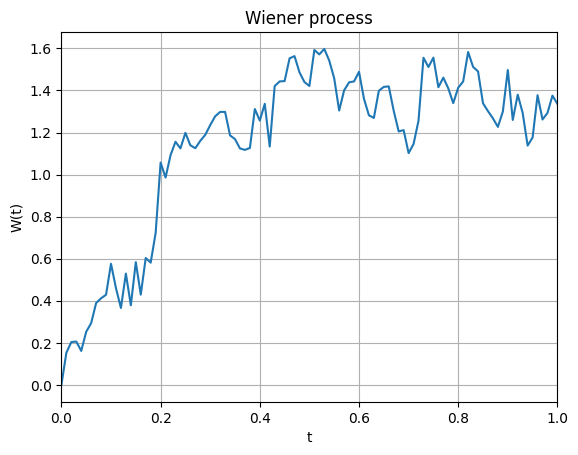

In [2]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

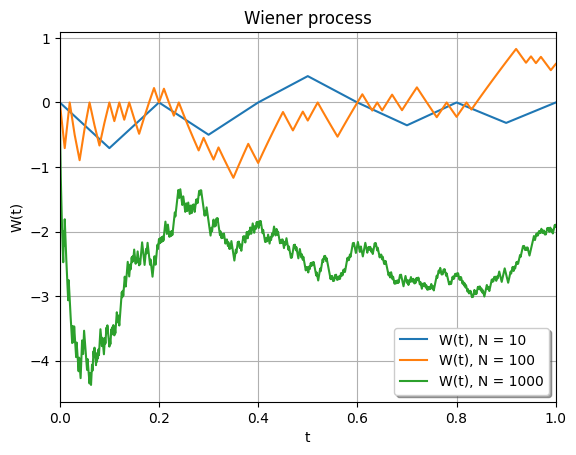

In [3]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

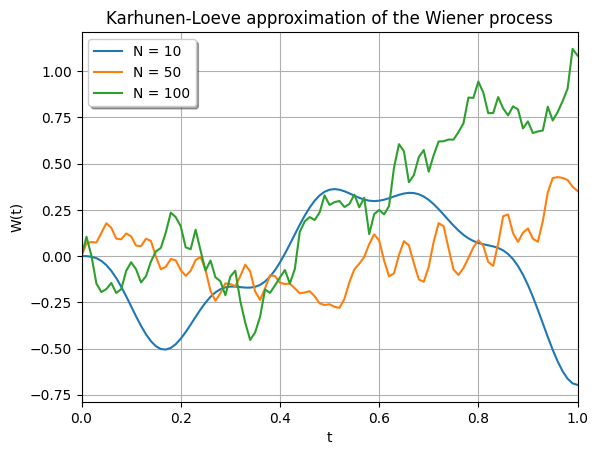

In [4]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data))
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

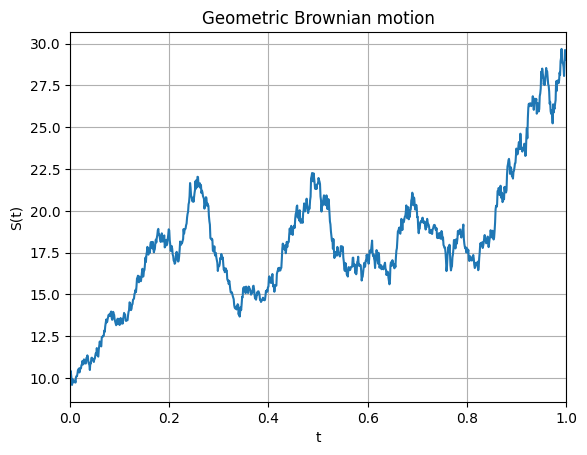

In [5]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

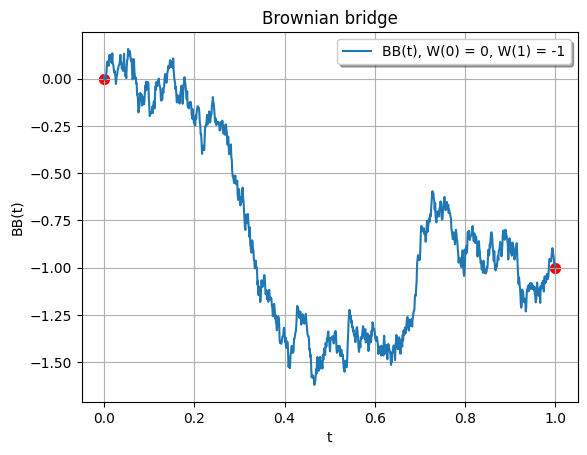

In [6]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

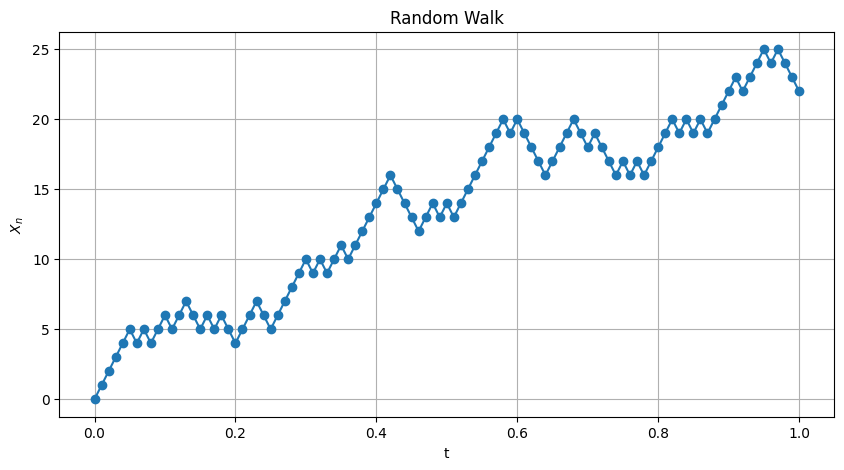

In [7]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()

RandomWalk(100)

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


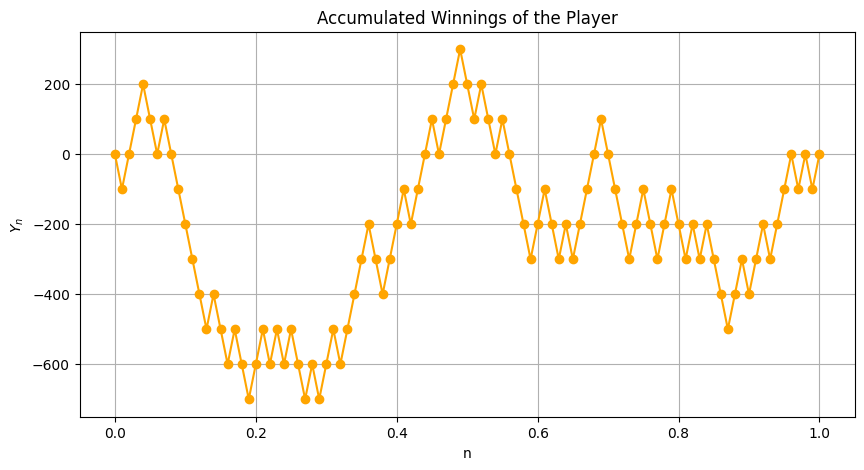

In [8]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

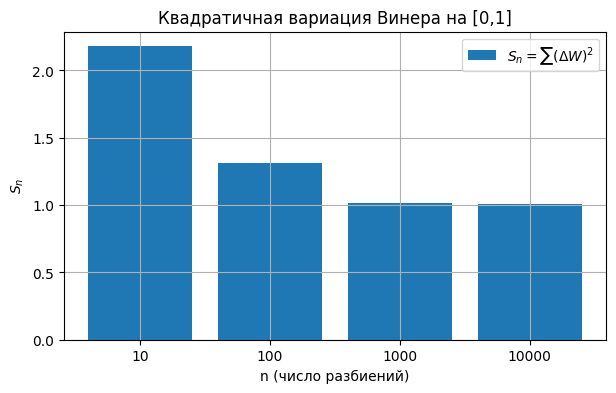

In [9]:
Ns = [10, 100, 1000, 10000]
S = []

for n in Ns:
    t_data, w_data = WienerProcess(n, 1)
    Sn = np.sum(np.diff(w_data)**2)
    S.append(Sn)

plt.figure(figsize=(7,4))
groups=[str(n) for n in Ns]
plt.bar(groups, S, label=r"$S_n=\sum (\Delta W)^2$")
plt.xlabel("n (число разбиений)")
plt.ylabel(r"$S_n$")
plt.title("Квадратичная вариация Винера на [0,1]")
plt.grid(True)
plt.legend()
plt.show()

Вывод: При увеличении числа разбиений сумма квадратов приращений не «разбегается», а стабилизируется около значения $T=1$. Это особенность винеровского процесса, которая отличает его от гладких функций: обычная вариация у траектории бесконечна, зато квадратичная вариация на отрезке $[0,1]$ стремится к длине отрезка. Небольшие отклонения столбцов от единицы — это нормальный эффект одной случайной реализации.


Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

In [10]:
M=500
list_half=[]
list_end=[]
N=100
h=int(N/2)
for n in range(M):
  t_data, w_data = WienerProcess(N, 1)
  list_half.append(w_data[h])
  list_end.append(w_data[-1])

c=np.cov(list_half,list_end)
print("значение ковариации между точками 0.5 и 1 равно", c[0,1])

значение ковариации между точками 0.5 и 1 равно 0.49301629247126405


**Вывод.** Выборочная ковариация между $W(0.5)$ и $W(1)$ получилась близкой к теоретическому значению $\min(0.5,1)=0.5$. Совпадение не обязано быть точным, потому что используется конечный ансамбль из 500 траекторий, но порядок и близость результата хорошо подтверждают формулу ковариации винеровского процесса. Если увеличить число траекторий, оценка обычно становится стабильнее.


Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапазон влияет на результат.

In [11]:
#500 траекторий мало, чтобы увидеть результат
M=5000
a=0.3
eps=0.01
N=100
s=int(0.4*N)
s_true=[]
for n in range(M):
  t_data, w_data = WienerProcess(N, 1)
  if (a-eps<=w_data[s]<=a+eps):
    s_true.append(w_data[-1])

m=np.mean(s_true)
print("среднее арифметические значение равно", m)

среднее арифметические значение равно 0.4024668328333486


**Вывод.** Среднее финальных значений траекторий, которые в момент $s=0.4$ проходят около уровня $a=0.3$, оказалось близко к самому уровню $0.3$. Это иллюстрирует мартингальное свойство: при известном текущем значении винеровского процесса лучшее среднее предсказание будущего значения равно текущему значению.

Ширина диапазона влияет на баланс между точностью и числом выбранных траекторий: слишком маленький диапазон даёт мало наблюдений и шумную оценку, а слишком широкий смешивает траектории с заметно разными значениями в момент $s$.


Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

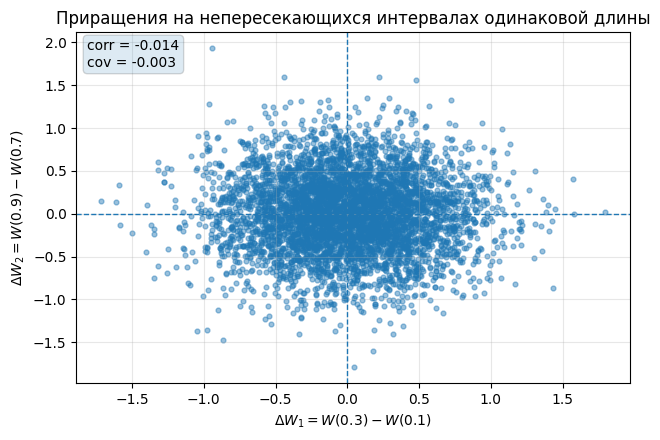

Коэффициент корреляции: -0.0140
Ковариация: -0.0028


In [12]:
M = 5000
N = 100

# Берём непересекающиеся интервалы одинаковой длины:
# [0.1, 0.3] и [0.7, 0.9], длина каждого равна 0.2.
t1, t2 = int(0.1 * N), int(0.3 * N)
t3, t4 = int(0.7 * N), int(0.9 * N)

dW1 = []
dW2 = []

for _ in range(M):
    t_data, w_data = WienerProcess(N, 1)
    dW1.append(w_data[t2] - w_data[t1])
    dW2.append(w_data[t4] - w_data[t3])

corr = np.corrcoef(dW1, dW2)[0, 1]
cov = np.cov(dW1, dW2)[0, 1]

plt.figure(figsize=(6.5, 4.5))
plt.scatter(dW1, dW2, alpha=0.45, s=12)
plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)
plt.xlabel(r"$\Delta W_1 = W(0.3)-W(0.1)$")
plt.ylabel(r"$\Delta W_2 = W(0.9)-W(0.7)$")
plt.title("Приращения на непересекающихся интервалах одинаковой длины")
plt.grid(True, alpha=0.3)

plt.text(
    0.02, 0.98,
    f"corr = {corr:.3f}\ncov = {cov:.3f}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()

print(f"Коэффициент корреляции: {corr:.4f}")
print(f"Ковариация: {cov:.4f}")


**Вывод.**

Важно, что `np.correlate(dW1, dW2)` не считает коэффициент корреляции Пирсона: это скалярное произведение массивов без центрирования и нормировки, поэтому число вроде $-0.96$ нельзя интерпретировать как корректную корреляцию между приращениями. В исправленном варианте используется `np.corrcoef(dW1, dW2)[0, 1]`.


Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.


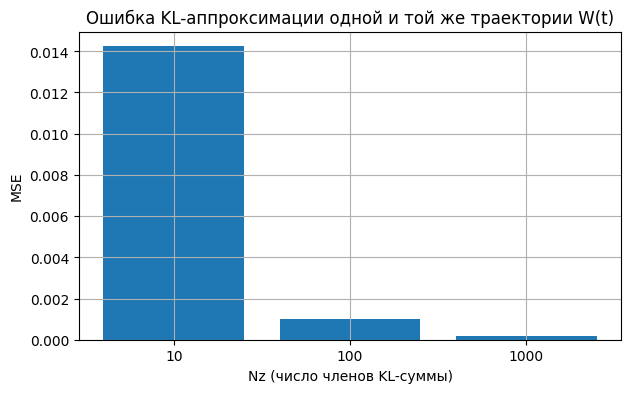

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def phi(k, t, T=1.0):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def lambda_k(k, T=1.0):
    # собственные числа для ядра min(s,t)
    return 4 * T**2 / ((2 * k + 1)**2 * np.pi**2)


T = 1.0
Nt = 1000
Nzs = [10, 100, 1000]


t_data, w_data = WienerProcess(Nt, T)
dt = T / Nt


maxNz = max(Nzs)
k_all = np.arange(maxNz)  # 0..maxNz-1
Phi = phi(k_all[:, None], t_data[None, :], T)  # shape: (maxNz, Nt+1)
lam = lambda_k(k_all, T)                        # shape: (maxNz,)

# 3) находим коэффициенты проекции c_k для аппроксимации w(t) = sum c_k * phi_k(t)
#    так как <phi_k, phi_k> = lambda_k, то c_k = <w,phi_k>/lambda_k
inner = (Phi * w_data[None, :]).sum(axis=1) * dt   # <w, phi_k> приближённо
c_all = inner / lam                                # коэффициенты c_k


MSE = []
for Nz in Nzs:
    w_approx = (c_all[:Nz, None] * Phi[:Nz, :]).sum(axis=0)  # восстановление по Nz модам
    mse = np.mean((w_data - w_approx)**2)
    MSE.append(mse)


x = np.arange(len(Nzs))
plt.figure(figsize=(7,4))
plt.bar(x, MSE)
plt.xticks(x, [str(n) for n in Nzs])
plt.xlabel("Nz (число членов KL-суммы)")
plt.ylabel("MSE")
plt.title("Ошибка KL-аппроксимации одной и той же траектории W(t)")
plt.grid(True)
plt.show()

**Вывод.** При увеличении числа членов разложения Карунена–Лоэва ошибка аппроксимации уменьшается: первые гармоники описывают общую форму траектории, а последующие добавляют более мелкие колебания. Поэтому при $n=10$ сохраняется только грубая структура, при $n=100$ приближение становится заметно точнее, а при $n=1000$ ряд уже хорошо восстанавливает выбранную траекторию. Небольшая остаточная ошибка связана с дискретной сеткой и численным приближением интегралов.
